# Level 3 Project 2 — GitHub Projects Data Analytics Pipeline

## Task 1: Data Collection & Preparation

In [129]:
import requests
import pandas as pd

In [130]:
# Step 1: Collect API Data
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response=requests.get(url)
data=response.json()

if response.status_code == 200 and 'items' in data:
    # Step 2: Create the Dataset
    df = pd.DataFrame(data['items'])
    print("--- Initial Data Structure ---")
    print(df.info())
else:
    print("Status code:", response.status_code)



--- Initial Data Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 

In [131]:
print("\n--- Preview ---")
print(df.head())


--- Preview ---
          id                           node_id                      name  \
0   45717250  MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==                tensorflow   
1  155220641  MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=              transformers   
2  343965132  MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=          ML-For-Beginners   
3  145553672  MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=                    funNLP   
4   21872392  MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==  awesome-machine-learning   

                               full_name  private  \
0                  tensorflow/tensorflow    False   
1               huggingface/transformers    False   
2             microsoft/ML-For-Beginners    False   
3                  fighting41love/funNLP    False   
4  josephmisiti/awesome-machine-learning    False   

                                               owner  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...   
1  {'login': 'huggingface', 'id': 25720743, 'node...   
2  {'login': 'microsoft', 'id': 6154722

In [132]:
print("\n--- Columns ---")
print(df.columns.tolist())


--- Columns ---
['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url', 'description', 'fork', 'url', 'forks_url', 'keys_url', 'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url', 'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url', 'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url', 'languages_url', 'stargazers_url', 'contributors_url', 'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url', 'comments_url', 'issue_comment_url', 'contents_url', 'compare_url', 'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url', 'milestones_url', 'notifications_url', 'labels_url', 'releases_url', 'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url', 'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size', 'stargazers_count', 'watchers_count', 'language', 'has_issues', 'has_projects', 'has_downloads', 'has_wiki', 'has_pages', 'has_discussions', 'forks_count', 'mirror_url', 'archived', 'disabled',

In [133]:
# Step 3: Select Required Columns
required_columns=['name', 'owner', 'language', 'stargazers_count', 
    'forks_count', 'watchers_count', 'open_issues_count', 
    'created_at', 'updated_at', 'license']

df=df[required_columns].copy()

In [134]:
# Step 4: Extract Required Values (Nested Data)
df["owner"] = df["owner"].apply(lambda x: x.get("login") if isinstance(x, dict) else None)
df["license"] = df["license"].apply(lambda x: x.get("name") if isinstance(x, dict) else None)

In [135]:
# Step 5: Handle Missing Values
print("\n--- Missing values before handling ---")
print(df.isnull().sum())


df['license']=df['license'].fillna('No License')
df['language']=df['language'].fillna("Unknown")

print("\n--- Missing values after handling ---")
df.isnull().sum()


--- Missing values before handling ---
name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64

--- Missing values after handling ---


name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64

In [136]:
# Step 6: Handle Duplicate Records

print("\nDuplicate rows before:",df.duplicated().sum()) # There is no duplicates but let's do it again

df = df.drop_duplicates()

print("\nDuplicate rows after:",df.duplicated().sum())



Duplicate rows before: 0

Duplicate rows after: 0


In [137]:
# Step 7: Prepare the Dataset
df['created_at']=pd.to_datetime(df['created_at'])
df['updated_at']=pd.to_datetime(df['updated_at'])

df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date",
})
print("\n--- Final columns ---")
print(df.columns.tolist())


--- Final columns ---
['name', 'owner', 'language', 'stars', 'forks', 'watchers', 'open_issues', 'created_date', 'updated_date', 'license']


In [138]:
print("\n--- Final preview ---")
print(df.head())


--- Final preview ---
                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  197075  76074   
1              transformers     huggingface            Python  164278  34293   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89583  21996   
3                    funNLP  fighting41love            Python   82560  15267   
4  awesome-machine-learning    josephmisiti            Python   74079  15614   

   watchers  open_issues              created_date              updated_date  \
0    197075         3105 2015-11-07 01:19:20+00:00 2026-08-20 07:19:22+00:00   
1    164278         2393 2018-10-29 13:56:00+00:00 2026-08-20 08:30:42+00:00   
2     89583           14 2021-03-03 01:34:05+00:00 2026-08-20 08:34:07+00:00   
3     82560           52 2018-08-21 11:20:39+00:00 2026-08-20 08:20:46+00:00   
4     74079           26 2014-07-15 19:11:19+00:00 2026-08-20 07:12:41+00:00   

              l

In [139]:
# Step 8: Save and Verify the Dataset
df.to_csv("github_projects.csv", index=False)
print("\nDataset saved as github_projects.csv")


Dataset saved as github_projects.csv


In [140]:
verify_df = pd.read_csv("github_projects.csv")
print("\n--- Verification ---")
print("Shape:", verify_df.shape)
print(verify_df.head())



--- Verification ---
Shape: (100, 10)
                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  197075  76074   
1              transformers     huggingface            Python  164278  34293   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89583  21996   
3                    funNLP  fighting41love            Python   82560  15267   
4  awesome-machine-learning    josephmisiti            Python   74079  15614   

   watchers  open_issues               created_date  \
0    197075         3105  2015-11-07 01:19:20+00:00   
1    164278         2393  2018-10-29 13:56:00+00:00   
2     89583           14  2021-03-03 01:34:05+00:00   
3     82560           52  2018-08-21 11:20:39+00:00   
4     74079           26  2014-07-15 19:11:19+00:00   

                updated_date             license  
0  2026-08-20 07:19:22+00:00  Apache License 2.0  
1  2026-08-20 08:30:42+00:00  Apache License 2.

## Task 2: Store & Analyse the Data

In [141]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


### Step 1: Create the SQLite Database

In [142]:
df = pd.read_csv("github_projects.csv")
print(df.columns.tolist())
conn = sqlite3.connect("github_projects.db")

df.to_sql("Repositories", conn, if_exists="replace", index=False)

cursor=conn.cursor()

print("✅ Database created and data imported successfully.\n")


['name', 'owner', 'language', 'stars', 'forks', 'watchers', 'open_issues', 'created_date', 'updated_date', 'license']
✅ Database created and data imported successfully.



In [143]:
def run_query(title, query):
    print(f"--- {title} ---")
    result = pd.read_sql_query(query, conn)
    print()
    return result

### Step 2: Filtering & Searching Queries

In [144]:
q1="""
SELECT name,owner,language,stars
FROM Repositories
WHERE stars > 10000
ORDER BY stars DESC;
"""

run_query("Repositories with more than 10,000 stars", q1)


--- Repositories with more than 10,000 stars ---



,name,owner,language,stars
0,tensorflow,tensorflow,C++,197075
1,transformers,huggingface,Python,164278
2,ML-For-Beginners,microsoft,Jupyter Notebook,89583
3,funNLP,fighting41love,Python,82560
4,awesome-machine-learning,josephmisiti,Python,74079
5,scikit-learn,scikit-learn,Python,66977
6,gradio,gradio-app,Python,43390
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36400
8,C-Plus-Plus,TheAlgorithms,C++,34589
9,netron,lutzroeder,JavaScript,33369


In [145]:
q2="""
SELECT name,owner,language,stars
FROM Repositories
WHERE name LIKE '%Machine%';
"""
run_query('Repositories with "Machine" in the name', q2)

--- Repositories with "Machine" in the name ---



,name,owner,language,stars
0,awesome-machine-learning,josephmisiti,Python,74079
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36400
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28864
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24770
4,awesome-production-machine-learning,EthicalML,Unknown,20854
5,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20539
6,stanford-cs-229-machine-learning,afshinea,Unknown,20132
7,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18114
8,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13956
9,machine-learning-interview,khangich,Unknown,12784


### Step 3: Logical Operators (AND, OR, NOT)

In [146]:
q3="""
SELECT name,stars,language,owner
FROM Repositories
WHERE language='Python' AND stars > 5000
ORDER BY stars DESC;
"""
run_query("Python repos with more than 5000 stars (AND)", q3)


--- Python repos with more than 5000 stars (AND) ---



,name,stars,language,owner
0,transformers,164278,Python,huggingface
1,funNLP,82560,Python,fighting41love
2,awesome-machine-learning,74079,Python,josephmisiti
3,scikit-learn,66977,Python,scikit-learn
4,gradio,43390,Python,gradio-app
5,ML-From-Scratch,32496,Python,eriklindernoren
6,linkedin-skill-assessments-quizzes,28804,Python,Ebazhanov
7,cs249r_book,27961,Python,harvard-edge
8,onnx,21335,Python,onnx
9,rasa,21297,Python,RasaHQ


In [147]:
q4="""
SELECT name,stars,language,owner
FROM Repositories
WHERE language='Python' OR language='JavaScript'
ORDER BY stars DESC;
"""
run_query("Python OR JavaScript repositories", q4)


--- Python OR JavaScript repositories ---



,name,stars,language,owner
0,transformers,164278,Python,huggingface
1,funNLP,82560,Python,fighting41love
2,awesome-machine-learning,74079,Python,josephmisiti
3,scikit-learn,66977,Python,scikit-learn
4,gradio,43390,Python,gradio-app
5,netron,33369,JavaScript,lutzroeder
6,ML-From-Scratch,32496,Python,eriklindernoren
7,linkedin-skill-assessments-quizzes,28804,Python,Ebazhanov
8,cs249r_book,27961,Python,harvard-edge
9,onnx,21335,Python,onnx


In [148]:
q5="""
SELECT name,stars,language,owner
FROM Repositories
WHERE NOT language='Unknown'
ORDER BY stars DESC
LIMIT 20;
"""
run_query("Repositories excluding Unknown language (NOT)", q5)

--- Repositories excluding Unknown language (NOT) ---



,name,stars,language,owner
0,tensorflow,197075,C++,tensorflow
1,transformers,164278,Python,huggingface
2,ML-For-Beginners,89583,Jupyter Notebook,microsoft
3,funNLP,82560,Python,fighting41love
4,awesome-machine-learning,74079,Python,josephmisiti
5,scikit-learn,66977,Python,scikit-learn
6,gradio,43390,Python,gradio-app
7,C-Plus-Plus,34589,C++,TheAlgorithms
8,netron,33369,JavaScript,lutzroeder
9,ML-From-Scratch,32496,Python,eriklindernoren


### Step 4: Sorting & Limiting Queries

In [149]:
q6="""
SELECT name, owner, language, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""
top10 = run_query("Top 10 repositories by stars", q6)
top10

--- Top 10 repositories by stars ---



,name,owner,language,stars
0,tensorflow,tensorflow,C++,197075
1,transformers,huggingface,Python,164278
2,ML-For-Beginners,microsoft,Jupyter Notebook,89583
3,funNLP,fighting41love,Python,82560
4,awesome-machine-learning,josephmisiti,Python,74079
5,scikit-learn,scikit-learn,Python,66977
6,gradio,gradio-app,Python,43390
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36400
8,C-Plus-Plus,TheAlgorithms,C++,34589
9,netron,lutzroeder,JavaScript,33369


### Step 5: Aggregate Functions

In [150]:
q7="""
SELECT 
COUNT(*) AS total_repositories,
ROUND(AVG(stars),2) AS average_stars
FROM Repositories;
"""
run_query("Total repositories and average stars", q7)



--- Total repositories and average stars ---



,total_repositories,average_stars
0,100,20811.19


### Step 6: Grouping Analysis

In [151]:
q8="""
SELECT language,COUNT(*) AS repo_count
FROM Repositories
GROUP BY language
HAVING COUNT(*)>5
ORDER BY repo_count DESC;"""
lang_group = run_query("Languages with more than 5 repositories", q8)
lang_group

--- Languages with more than 5 repositories ---



,language,repo_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


### Step 7: Create Python Visualizations


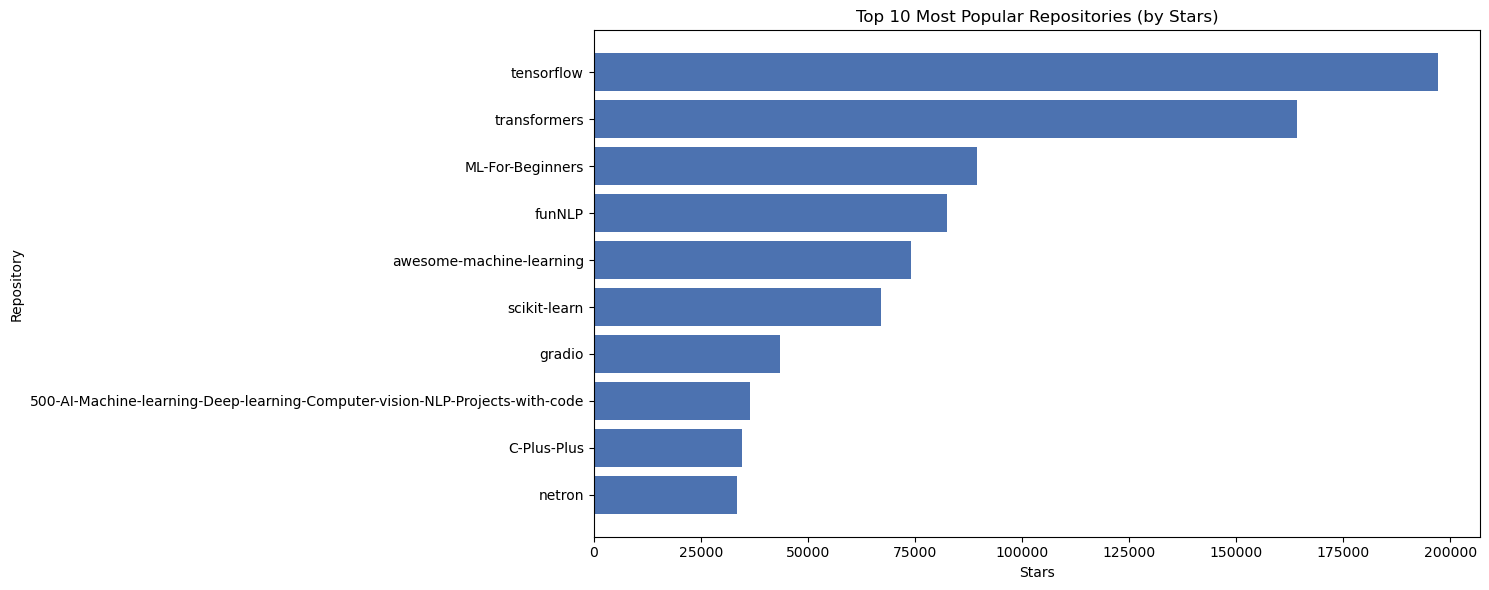

In [152]:
# Chart 1: Top 10 most popular repositories (bar chart)
plt.figure(figsize=(15,6))
plt.barh(top10['name'],top10['stars'],color="#4C72B0")
plt.xlabel("Stars")
plt.ylabel("Repository")
plt.title("Top 10 Most Popular Repositories (by Stars)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top10_repositories.png")
plt.show()

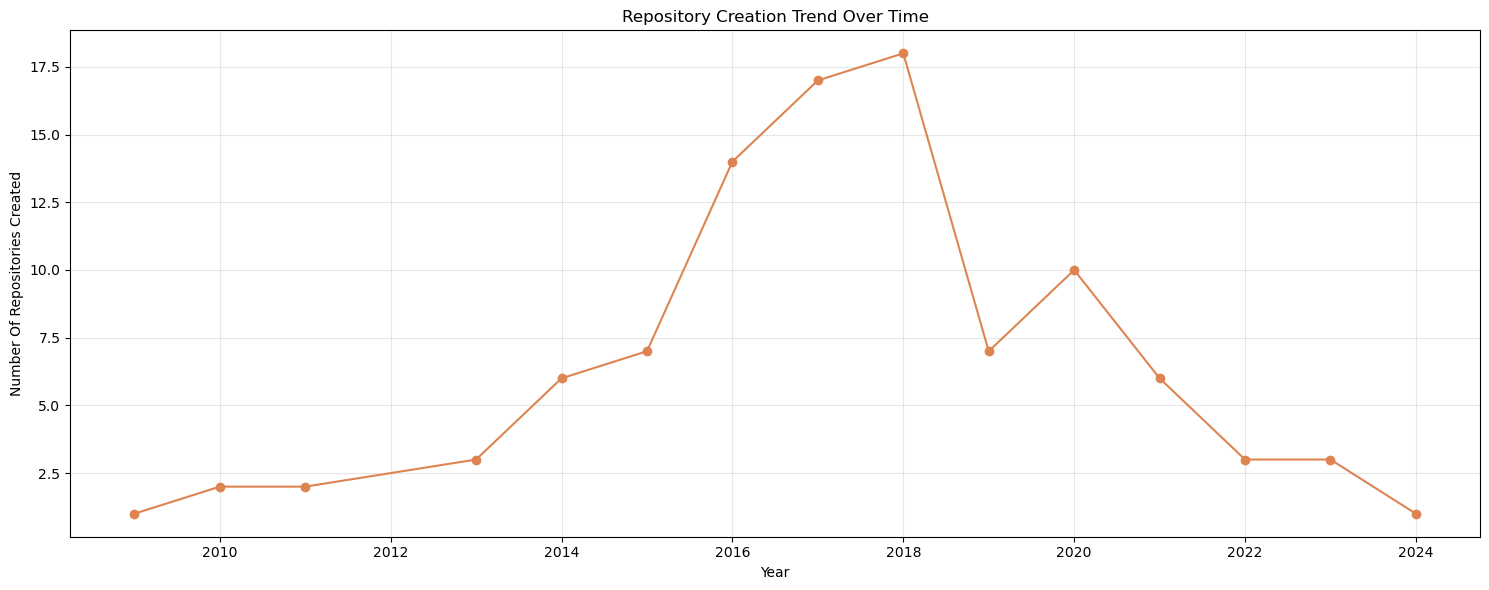

In [153]:
# Chart 2: Repository creation trend over time (line chart)
df['created_date']=pd.to_datetime(df['created_date'])
df['created_year']=df['created_date'].dt.year

yearly_counts=df.groupby('created_year').size()

plt.figure(figsize=(15,6))
plt.plot(yearly_counts.index,yearly_counts.values,marker="o",color="#DD8452")
plt.xlabel('Year')
plt.ylabel('Number Of Repositories Created')
plt.title("Repository Creation Trend Over Time")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig("creation_trend.png")
plt.show()

## Interpretation of Results

### 1. Repository Creation Trend Over Time
Steady growth from 2009 to 2018: The number of repositories created rose almost continuously, from just 1 repository in 2009 to a peak of 18 repositories in 2018. This mirrors the real explosion of interest in Machine Learning during that period — driven by the release of TensorFlow (2015) and the rapid adoption of libraries like scikit-learn and PyTorch.
Sharp drop after 2018: The count fell from 18 in 2018 to just 7 in 2019. This doesn't necessarily mean interest declined — rather, most of the major "foundational" ML projects had already been created by then, making it harder for newer repos to break into a Top-100-by-stars sample.
A spike in 2020 (10 repositories) likely reflects increased research activity and self-learning during the COVID-19 pandemic, when many developers turned to open-source ML projects.
Gradual decline from 2020 to 2024: Counts steadily decrease (10 → 1). This is largely a sampling effect — since the dataset was pulled sorted by highest stars, newer repositories (2022–2024) simply haven't had enough time to accumulate stars and qualify for this "most popular" sample, not because fewer projects are being created.


### 2. Most Popular Repositories (Top 10 by Stars)
TensorFlow (~197K stars) and Transformers (~165K stars) dominate the list by a wide margin, confirming that core frameworks and libraries attract by far the largest developer communities compared to individual application projects.
The rest of the list (ML-For-Beginners, funNLP, awesome-machine-learning, scikit-learn, etc.) ranges roughly between 35K–90K stars — but notably, most of these are educational resources or curated "awesome lists" rather than production tools, showing that the community heavily values learning resources alongside technical libraries.
scikit-learn's continued presence in the Top 10 — despite being one of the older projects in the dataset — highlights the long-term staying power of well-maintained, foundational libraries versus newer, trend-driven repositories.
Overall, popularity (stars) is concentrated in a small number of foundational tools, while the "long tail" of repositories has comparatively low visibility — a pattern typical of open-source ecosystems where a few flagship projects anchor the whole community.


### 3. Key Business Takeaway
Organizations investing in ML tooling should prioritize contributing to or building on top of already-dominant, actively maintained frameworks (TensorFlow, Transformers, scikit-learn) rather than competing with standalone new tools — since community trust and adoption are heavily concentrated at the top, and newer projects need significant time before they can compete on visibility and adoption.

## Task 3: Manage the Project Using Git and GitHub

### Step 7: Ethics Reflection

**Q1: Why is it important to verify data collected from public APIs?**

Public APIs like the GitHub API return data that can change frequently, be incomplete, or occasionally contain inconsistencies (for example, missing `language` or `license` fields, as seen in this dataset where 23 repositories had no language and 22 had no license listed). Verifying the data before analysis ensures that the conclusions drawn — such as which languages or repositories are most popular — are based on accurate, trustworthy values rather than errors, nulls, or unexpected formats. Without verification, an analyst risks building an entire report on top of flawed inputs, which can silently propagate incorrect conclusions.

**Q2: Why should data analysts document the source of their data?**

Documenting the data source (in this case, the GitHub Search API, endpoint `search/repositories`, filtered by `machine+learning`, sorted by stars) allows anyone reviewing the analysis to understand exactly how the dataset was collected, what scope or filters were applied, and when it was pulled. This is essential for reproducibility (someone else could re-run the same query and compare results), for identifying potential bias introduced by the collection method (e.g., only the top 100 most-starred repositories were retrieved, not a random or complete sample), and for maintaining accountability — if a mistake is later found in the data, the documented source makes it possible to trace back and correct it.

**Q3: How can missing or inaccurate data affect data analysis and decision-making?**

Missing or inaccurate data can distort summary statistics (e.g., averages, counts, groupings) and lead to misleading visualizations or conclusions. In this project, missing `language` and `license` values were handled by filling them with `"Unknown"` and `"No License"` rather than dropping the rows, which preserves the repositories in the dataset while clearly flagging that the information was not available — avoiding both data loss and false assumptions. If such gaps were ignored or filled incorrectly (e.g., silently assumed to be a specific license), any business or research decision based on that analysis — such as recommending a framework to invest in — could be built on inaccurate premises, reducing trust in the results and potentially leading to poor decisions.

**Summary:** Working with data from a public API required verifying its structure, documenting exactly where and how it was collected, and handling missing values responsibly rather than ignoring them. These practices ensure the analysis in Task 1 and Task 2 is transparent, reproducible, and reliable for anyone reviewing this project.
